In [1]:
import os
import yaml as pyyaml

docker_compose_dir = r"C:\Users\mario\OneDrive\Documentos\UPM\Master_Data\TFM_Project\data\docker_compose\Envoy"

docker_compose_files = []

for q in os.listdir(docker_compose_dir):
    docker_compose_file = os.path.join(docker_compose_dir, q, "docker-compose.yaml")
    if os.path.isfile(docker_compose_file):
        # parse the docker-compose file as a YAML file
        with open(docker_compose_file, "r") as f:
            docker_compose = pyyaml.safe_load(f)
            docker_compose_files.append(docker_compose)

In [2]:
key_count = {}
key_levels = {}

for docker_compose in docker_compose_files:
    for key, value in docker_compose.items():
        if key in key_count:
            key_count[key] += 1
        else:
            key_count[key] = 1

        if key in key_levels:
            key_levels[key].append(1)
        else:
            key_levels[key] = [1]

        if isinstance(value, dict):
            for subkey, subvalue in value.items():
                if subkey in key_count:
                    key_count[subkey] += 1
                else:
                    key_count[subkey] = 1

                if subkey in key_levels:
                    key_levels[subkey].append(2)
                else:
                    key_levels[subkey] = [2]

                if isinstance(subvalue, dict):
                    for subsubkey, subsubvalue in subvalue.items():
                        if subsubkey in key_count:
                            key_count[subsubkey] += 1
                        else:
                            key_count[subsubkey] = 1
                        
                        if subsubkey in key_levels:
                            key_levels[subsubkey].append(3)
                        else:
                            key_levels[subsubkey] = [3]


C:\Users\mario\AppData\Local\Temp\ipykernel_11300\3537909840.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_count.set_xticklabels(ax_count.get_xticklabels(), rotation=90)


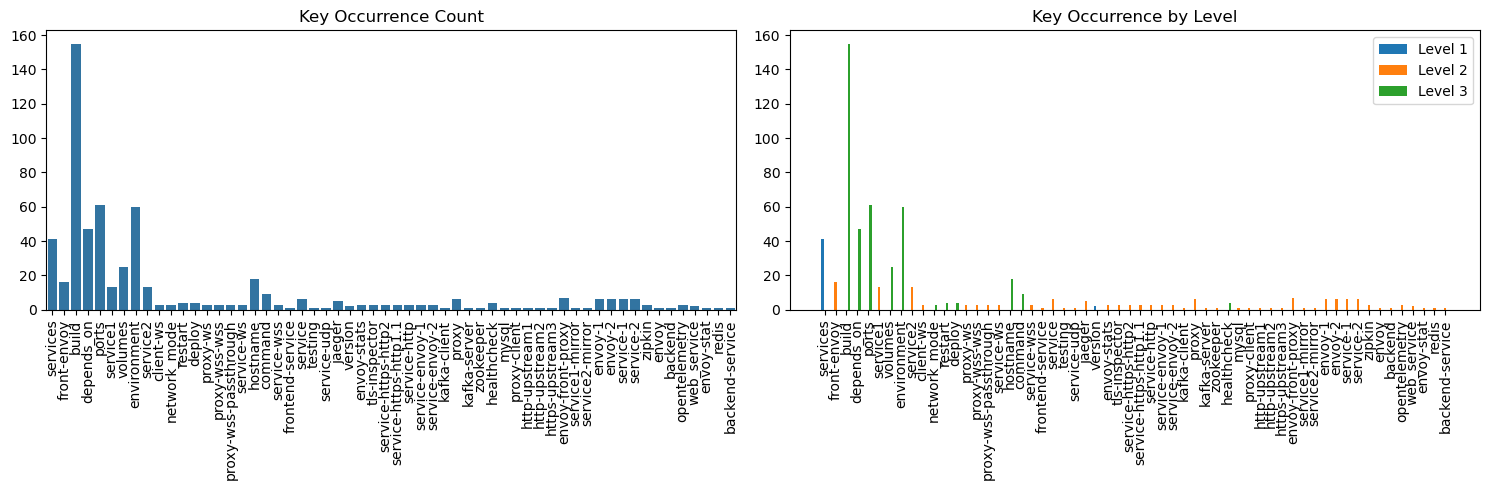

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ax_count, ax_level = axs[0], axs[1]

sns.barplot(x=list(key_count.keys()), y=list(key_count.values()), ax=ax_count)
ax_count.set_title("Key Occurrence Count")
ax_count.set_xticklabels(ax_count.get_xticklabels(), rotation=90)

# For each key, generate a bar for each level. The y-axis will represent the count of occurrences at that level.
keys = list(key_levels.keys())
counts = []

for key in keys:
    level_counts = Counter(key_levels[key])
    counts.append([level_counts.get(1, 0), level_counts.get(2, 0), level_counts.get(3, 0)])

counts = np.array(counts)
bar_width = 0.2

for i in range(3):
    ax_level.bar(np.arange(len(keys)) + i * bar_width, counts[:, i], width=bar_width, label=f"Level {i+1}")

ax_level.set_title("Key Occurrence by Level")
ax_level.set_xticks(np.arange(len(keys)) + bar_width)
ax_level.set_xticklabels(keys, rotation=90)
ax_level.legend()
plt.tight_layout()


In [ ]:
import accelerate
import bitsandbytes as bnb
import torch
import transformers
import os

from transformers import BitsAndBytesConfig, AutoTokenizer, AutoModelForCausalLM

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda:", torch.version.cuda)
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

print("transformers:", transformers.__version__)


print("bitsandbytes:", bnb.__version__)
print("bnb file:", bnb.__file__)
print("accelerate:", accelerate.__version__)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

torch: 2.4.1
cuda available: True
torch cuda: 12.1
gpu: NVIDIA GeForce RTX 3060 Laptop GPU
transformers: 4.51.3
bitsandbytes: 0.46.1
bnb file: c:\Users\mario\anaconda3\envs\torch-transformer\lib\site-packages\bitsandbytes\__init__.py
accelerate: 1.12.0


In [1]:
from data_profiler.prompt_data_profiler import PromptDataProfiler

In [ ]:
prompt_profiler = PromptDataProfiler(root_dir=".")

prompt_profiler.run()

,service,question_id,variant,file_path,prompt,prompt_clean,char_count,line_count,sentence_count,tokens,...,unique_word_count,lexical_diversity,avg_word_length,avg_sentence_length_words,digit_ratio,uppercase_ratio,question_mark_count,colon_count,comma_count,bullet_like_count
0,Envoy,q1,question,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Can you create a YAML file with three main sec...,Can you create a YAML file with three main sec...,708,6,6,"[can, you, create, yaml, file, with, three, ma...",...,76,0.666667,5.008772,19.000000,0.000000,0.020942,1,0,5,0
1,Envoy,q1,question_simplified,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Create a YAML file with 3 sections defining ca...,Create a YAML file with 3 sections defining ca...,358,5,6,"[create, yaml, file, with, sections, defining,...",...,39,0.795918,5.836735,8.166667,0.013966,0.031802,0,3,3,0
2,Envoy,q10,question,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Here is the current Envoy config I'm working w...,Here is the current Envoy config I'm working w...,915,24,24,"[here, is, the, current, envoy, config, workin...",...,79,0.759615,6.144231,4.333333,0.007650,0.091493,1,16,5,4
3,Envoy,q10,question_simplified,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Complete the YAML by filling in the [TO COMPLE...,Complete the YAML by filling in the [TO COMPLE...,786,20,22,"[complete, the, yaml, by, filling, in, the, to...",...,63,0.768293,6.670732,3.727273,0.008906,0.096958,0,15,2,4
4,Envoy,q11,question,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Can you provide a YAML configuration for an En...,Can you provide a YAML configuration for an En...,1426,11,28,"[can, you, provide, yaml, configuration, for, ...",...,105,0.558511,6.319149,6.714286,0.009116,0.044866,1,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Kubernetes,q97,question_simplified,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Create a Kubernetes Ingress YAML manifest to r...,Create a Kubernetes Ingress YAML manifest to r...,222,2,1,"[create, kubernetes, ingress, yaml, manifest, ...",...,27,0.729730,4.810811,37.000000,0.054054,0.158537,0,0,2,0
644,Kubernetes,q98,question,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Create a Kubernetes Ingress YAML file to route...,Create a Kubernetes Ingress YAML file to route...,192,3,2,"[create, kubernetes, ingress, yaml, file, to, ...",...,26,0.838710,4.903226,15.500000,0.015625,0.087838,0,0,0,0
645,Kubernetes,q98,question_simplified,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,Create a k8s Ingress YAML to route incoming HT...,Create a k8s Ingress YAML to route incoming HT...,167,2,2,"[create, k8s, ingress, yaml, to, route, incomi...",...,24,0.888889,4.888889,13.500000,0.023952,0.094488,0,0,0,0
646,Kubernetes,q99,question,C:\Users\mario\OneDrive\Documentos\UPM\Master_...,"In Kubernetes, create an Ingress resource call...","In Kubernetes, create an Ingress resource call...",379,4,4,"[in, kubernetes, create, an, ingress, resource...",...,36,0.620690,5.000000,14.500000,0.021108,0.035336,0,1,1,0
